In [1]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
# include(joinpath(functions_directory, "load_model_starting_points_OLD.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected_with_MVP.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))
include(joinpath(functions_directory, "create_vaccine_data_MMR_only.jl"))

create_vaccine_data_MMR_only (generic function with 1 method)

In [2]:
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data_MMR_only()

(["Measles", "Mumps", "Rubella"], ["M", "MR", "MMR"], Dict("MMR" => ["Measles", "Mumps", "Rubella"], "MR" => ["Measles", "Rubella"], "M" => ["Measles"]), ["Biological_E", "GSK", "PT_Bio", "Serum_Institute"], Dict("MMR" => ["Serum_Institute", "GSK"], "MR" => ["Serum_Institute", "Biological_E"], "M" => ["Serum_Institute", "PT_Bio"]), Dict("Measles" => ["MMR", "MR", "M"], "Mumps" => ["MMR"], "Rubella" => ["MMR", "MR"]), Dict("Serum_Institute" => ["MMR", "MR", "M"], "Biological_E" => ["MR"], "GSK" => ["MMR"], "PT_Bio" => ["M"]), Dict("Measles" => ["Serum_Institute", "GSK", "Biological_E", "PT_Bio"], "Mumps" => ["Serum_Institute", "GSK"], "Rubella" => ["Serum_Institute", "GSK", "Biological_E"]), Dict("Serum_Institute" => ["Measles", "Mumps", "Rubella"], "Biological_E" => ["Measles", "Rubella"], "GSK" => ["Measles", "Mumps", "Rubella"], "PT_Bio" => ["Measles"]), Dict("Medium" => ["Sanofi", "Pfizer", "Haffkine_Bio", "Bharat_Biotech", "Merck_Sharp", "PT_Bio", "LG_Chem", "BB_NCIPD"], "Small" =>

In [ ]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, 1000, A, V)

In [3]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, beta, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(data_dir, 1000, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Serum_Institute" => 587114.0, "Biological_E" => 164886.0, "GSK" => 226763.0, "PT_Bio" => 45912.0), Dict{Any, Any}(("MMR", "Serum_Institute", 5) => 2.2953333333333332, ("M", "PT_Bio", 5) => 0.2675, ("M", "Serum_Institute", 8) => 0.436734375, ("MR", "Serum_Institute", 5) => 0.890625, ("MR", "Serum_Institute", 10) => 0.89083984375, ("MMR", "GSK", 8) => 4.47, ("MR", "Serum_Institute", 2) => 0.8925000000000001, ("MR", "Biological_E", 3) => 0.87, ("M", "PT_Bio", 4) => 0.265, ("MR", "Biological_E", 8) => 0.92121875…), Dict{Any, Any}(("MMR", 1) => 3.207, ("MMR", 2) => 3.303166666666667, ("MMR", 8) => 3.372729166666667, ("M", 6) => 0.35134375, ("MR", 4) => 0.917875, ("MR", 10) => 0.905447265625, ("M", 8) => 0.35164843749999997, ("MR", 6) => 0.9084062500000001, ("M", 9) => 0.35180078125, ("MMR", 9) => 3.3743854166666667…), Dict{Any, Any}("Serum_Institute" => 1.1832658854166667, "Biological_E" =

In [4]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios = process_scenario_data_n_selected(current_directory, data_dir, 3, 3, A, T, P, 1, 10, 5, 1, 1, 1, 1)

(Dict("Partial_1" => [4], "All" => [4, 5, 6, 7, 8, 9, 1, 2, 3], "Partial_2" => [5, 6, 7, 8, 9, 1, 2, 3]), Dict(5 => 0.021174243267633855, 4 => 0.0184294339551628, 6 => 0.016116892748786363, 7 => 0.0015552801502578839, 2 => 0.08077581690986248, 9 => 0.00037874697959647957, 8 => 0.0016600399531249953, 3 => 0.07567831390098767, 1 => 0.7842312321345873), Dict(5 => 0.02157179931846758, 6 => 0.01641949474272455, 7 => 0.0015844812426729189, 2 => 0.08229241962230226, 9 => 0.00038585812645402693, 8 => 0.0016912079585006286, 3 => 0.07709920867526376, 1 => 0.7989555303136142), [4], [5, 6, 7, 8, 9, 1, 2, 3], 4, Dict{Any, Any}(("GSK", 2, 5) => 226763.0, ("PT_Bio", 2, 7) => 45912.0, ("GSK", 6, 6) => 226763.0, ("Biological_E", 3, 3) => 164886.0, ("Biological_E", 8, 1) => 164886.0, ("Biological_E", 5, 9) => 164886.0, ("Biological_E", 7, 9) => 164886.0, ("GSK", 7, 8) => 226763.0, ("GSK", 8, 4) => 226763.0, ("Biological_E", 7, 8) => 164886.0…), Dict{Any, Any}(("Rubella", 8, 7) => 670139.0, ("Mumps", 5, 

In [5]:
gurobi_solver = JuMP.optimizer_with_attributes(Gurobi.Optimizer, "FeasibilityTol" => 1e-3, "OutputFlag" => 0, "Presolve" => 0, "NumericFocus" => 1, "Heuristics" => 0.5, "PumpPasses" => 10, "GomoryPasses"=>2)
Masterproblem = JuMP.Model()
JuMP.set_optimizer(Masterproblem, gurobi_solver)


 @variable(Masterproblem, 0.0 <= F[a in A, (t, tau) in F_time_set] <= 1.0, Bin)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-10-04
Set parameter FeasibilityTol to value 0.001


2-dimensional DenseAxisArray{VariableRef,2,...} with index sets:
    Dimension 1, ["Measles", "Mumps", "Rubella"]
    Dimension 2, Any[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6)  …  (7, 7), (7, 8), (7, 9), (7, 10), (8, 8), (8, 9), (8, 10), (9, 9), (9, 10), (10, 10)]
And data, a 3×40 Matrix{VariableRef}:
 F[Measles,(1, 1)]  F[Measles,(1, 2)]  …  F[Measles,(10, 10)]
 F[Mumps,(1, 1)]    F[Mumps,(1, 2)]       F[Mumps,(10, 10)]
 F[Rubella,(1, 1)]  F[Rubella,(1, 2)]     F[Rubella,(10, 10)]

In [6]:
num_vars = JuMP.num_variables(Masterproblem)


120

In [ ]:
d_real_tilde[("Rubella",1,1)]

In [36]:
# single cut
new_updated_data = {"lb":[2.969608646839243e6,4.728080218060145e6,5.985883845002955e6,7.60080029046311e6,8.281951653208381e6,9.369544792595018e6,1.085331371810548e7,1.085331371810549e7,1.1542599771243215e7,1.2652756231607491e7,1.348674989329056e7,1.4109302890715087e7,1.500833253976653e7,1.5544224467400819e7,1.6295843618636347e7,1.7037457104030505e7,1.7748767606793333e7,1.8583197887014672e7,1.9092766006589316e7,1.995899011703951e7,2.0404857542882543e7,2.088888282465606e7,2.1259368409023315e7,2.1791444992716588e7,2.252661643201492e7,2.3007072458263427e7,2.3411684112509154e7,2.408221973339476e7,2.453815794587419e7,2.4803275745690037e7,2.526942459307213e7,2.573262187774158e7,2.6221176531991575e7,2.6710037810236998e7,2.7210194001362912e7,2.7508251558037784e7,2.7863827406263232e7,2.8175103659525506e7,2.8481786652570546e7,2.8827407150776453e7,2.929860515030378e7,2.976543943921102e7,3.003345768952266e7,3.0357346112001754e7,3.0726197975175582e7,3.109325234836799e7,3.1416790438396446e7,3.171354798849485e7,3.2104353644023314e7,3.2443214389651336e7,3.2793760742871873e7,3.3121662337764483e7,3.3487183050553557e7,3.380007364718146e7,3.412003415233487e7,3.447155338145076e7,3.477232551541975e7,3.5190405403395034e7,3.553907872101051e7,3.582327488388212e7,3.603266102691613e7,3.638967804406898e7,3.6776793370491266e7,3.702857430404777e7,3.752618772715608e7,3.795719071362673e7,3.8363577078780115e7,3.89104386244062e7,3.920746726609185e7,3.95153443174791e7,3.972052519413714e7,4.000885827726291e7,4.021778879596959e7,4.049805400952889e7,4.0826356277294055e7,4.1096606849514745e7,4.146231397208478e7,4.1782283416015126e7,4.204448124359114e7,4.223891874226071e7,4.246334051130302e7,4.2694240403698646e7,4.2870409770062044e7,4.3134291639485e7,4.336587403980787e7,4.368207383390926e7,4.390964991484131e7,4.418742678425422e7,4.440222054044266e7,4.465856398557151e7,4.494296111351166e7,4.512226074548879e7,4.5382177234227225e7,4.554490255854731e7,4.589742164920639e7,4.631011662079987e7,4.6672671725928694e7,4.694174870103034e7,4.722294340529812e7,4.75836448919574e7,4.783009549836018e7,4.803666612651935e7,4.8234624910351545e7,4.844578261765784e7,4.871374584148695e7,4.893045275666253e7,4.9098405649113e7,4.9294562319398984e7,4.948954375172851e7,4.98251424611033e7,5.006474055124591e7,5.027178629793866e7,5.060446026095414e7,5.089336134235038e7,5.1146518885505125e7,5.131011400674422e7,5.1485827641525745e7,5.1689601335985094e7,5.185158298306305e7,5.199248534291762e7,5.216381940023117e7,5.234283982341281e7,5.2549780525792696e7,5.2729847976248875e7,5.291250359276184e7,5.309521949962281e7,5.328489766802344e7,5.345728938744582e7,5.36829278087844e7,5.392669453107539e7,5.4093947963582985e7,5.43914461198957e7,5.4692769102288544e7,5.4905856094645314e7,5.519601227614545e7,5.55374285960803e7,5.583152493443544e7,5.6154780606878e7,5.6428289050945476e7,5.6737419162948504e7,5.692671766905616e7,5.714913815180357e7,5.738942492186393e7,5.758802071756679e7,5.780903474231987e7,5.80109988880534e7,5.821723599811944e7,5.839620854311136e7,5.865854251585196e7,5.887364048151146e7,5.912368970899673e7,5.936511881529733e7,5.96082065885086e7,5.989075087333292e7,6.013507503061703e7,6.026937191073106e7,6.048707247757435e7,6.0791273519025564e7,6.099183511838627e7,6.1275912105138965e7,6.150701442044592e7,6.179010042145786e7,6.195022002021478e7,6.218740236761175e7,6.241872158689869e7,6.265117551158444e7,6.2940301032323904e7,6.319894090615974e7,6.338355347959906e7,6.365546758912243e7,6.388507014002317e7,6.407045315280509e7,6.4275548712677404e7,6.460392828161969e7,6.4834725343847856e7,6.501011330976574e7,6.516831021212244e7,6.533274864932958e7,6.550859942163113e7,6.5708817914026745e7,6.601454722345113e7,6.623499545835692e7,6.6441392169912845e7,6.675940515113427e7,6.694146305515283e7,6.715928768390405e7,6.729581947505629e7,6.748158718315575e7,6.76255255499529e7,6.780021281791824e7,6.8084917745909e7,6.825052082969669e7,6.845759855379255e7,6.877158099341483e7,6.901257577287154e7,6.926808789692591e7,6.948434854379103e7,6.96806460320345e7,6.997555178777575e7,7.021391045371056e7,7.051079280627714e7,7.066187691242798e7,7.081343899893057e7,7.099472357363361e7,7.122315360981506e7,7.143299760875396e7,7.170659072855277e7,7.192484810792617e7,7.207794988241562e7,7.223430984753184e7,7.238773953692946e7,7.258351036233723e7,7.279075762104112e7,7.296509476639858e7,7.32943302947322e7,7.352771521317574e7,7.376188187902234e7,7.40849835466207e7,7.440674138271424e7,7.468158487199228e7,7.498043307641906e7,7.528371216745788e7,7.555946671533433e7,7.580926806131953e7,7.607456873681915e7,7.6348843377426e7,7.662468142969868e7,7.69015136007644e7,7.718157466639346e7,7.749372069987415e7,7.769752242776702e7,7.782815010398099e7,7.81082248730386e7,7.83059809328423e7,7.845402652385807e7,7.863747933811155e7,7.880916979318815e7,7.908199878650916e7,7.932209104547936e7,7.958521353237674e7],"ub":[1.7714913338414974e9,1.4043175258616347e9,1.0583523781615435e9,1.019224078050654e9,9.731811259223406e8,8.686412575632932e8,8.686412575632932e8,8.686412575632932e8,8.644712545399022e8,8.644712545399022e8,8.373848008516626e8,7.468269824742634e8,7.46474668827153e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,6.097166512880522e8,5.617734592959845e8,5.617734592959845e8,5.617734592959845e8,5.617734592959845e8,5.617734592959845e8,5.566869579638017e8,5.566869579638017e8,5.390895200837421e8,5.390895200837421e8,5.390895200837421e8,5.390895200837421e8,5.110764000528636e8,5.110764000528636e8,5.110764000528636e8,5.110764000528636e8,5.110764000528636e8,5.110764000528636e8,4.811767087850423e8,4.811767087850423e8,4.811767087850423e8,4.811767087850423e8,4.811767087850423e8,4.811767087850423e8,4.811767087850423e8,4.61416479827487e8,4.61416479827487e8,4.567331891087862e8,4.395595476026881e8,4.395595476026881e8,4.395595476026881e8,4.395595476026881e8,4.386238625341118e8,3.963399367526187e8,3.8865115339752877e8,3.8865115339752877e8,3.8865115339752877e8,3.8865115339752877e8,3.708023868106159e8,3.708023868106159e8,3.708023868106159e8,3.708023868106159e8,3.708023868106159e8,3.708023868106159e8,3.708023868106159e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.6321084993945205e8,3.52466691785584e8,3.461371285252904e8,3.461371285252904e8,3.461371285252904e8,3.461371285252904e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,3.25123210219057e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.949459871155089e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.783987452811981e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8,2.52868489835463e8]}

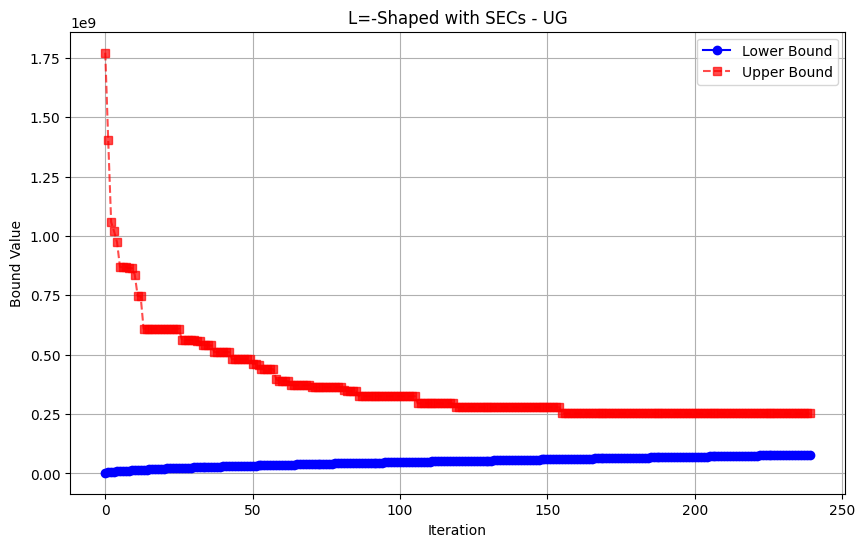

In [37]:
import matplotlib.pyplot as plt

# # Adjust the length of both lists to match the shorter one
# min_length = min(len(lower_bounds), len(upper_bounds))

# # Trim both lists to the same length
# lower_bounds = lower_bounds[:min_length]
# upper_bounds = upper_bounds[:min_length]
# iterations = list(range(min_length))

# Plot the adjusted lower and upper bounds
plt.figure(figsize=(10, 6))
# Plot lower and upper bounds
plt.plot(new_updated_data["lb"], label="Lower Bound", marker="o", linestyle="-", color="blue")
plt.plot(new_updated_data["ub"], label="Upper Bound", marker="s", linestyle="--", color="red", alpha=0.7)

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Bound Value")
plt.title("L=-Shaped with SECs - UG")
plt.legend()
plt.grid(True)
# plt.savefig("UG_L_shaped_trust_region.pdf")
# Show the plot
plt.show()


In [ ]:
            if iter2 >= 2
                println("Generating trust region cuts")
                # F variable
                try
                    unregister(Masterproblem, :trust_region_constr_all)
                catch e
                    println("No constraint: ", e)
                finally
                    trust_expr_F = sum(
                        F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
                                                  Masterproblem[:F][a, (t, tau)]
                        for a in A, (t, tau) in F_time_set
                    )

                    trust_expr_Y = sum(
                            Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
                            for p in P, t in T
                        )

                    trust_expr_L = sum(
                        L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
                        for p in P, t in T
                    )

                    trust_expr_Z = sum(
                            Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
                            for v in V, p in P_v[v], t in T, m in keys(m_segments)
                        )

                    trust_expr_all = trust_expr_F + trust_expr_Y + trust_expr_L + trust_expr_Z
                    @constraint(Masterproblem, trust_region_constr_all, trust_expr_all <= trust_delta_F)
                end
            end

In [ ]:
            # # add solution elimination constraints (Masterproblem, iter, Z_M, Z_M_prev) - create a function for this - MULTIPLE TRUST REGIONS FOR EACH BINARY
            # if iter2 == 1
            #     trust_delta_F = max_horizon_length * max_tender_length * length(A)/ 2
            #     trust_delta_Y = length(P) * length(T) / 2
            #     trust_delta_L = length(P) * length(T) / 2
            #     trust_delta_Z = length(V) * length(P) * length(T) * length(m_segments) /2
            # elseif iter2 >= 2
            #     if Z_M >= Z_M_prev
            #         trust_delta_F = ceil(1.3*trust_delta_F)
            #         trust_delta_Y = ceil(1.3*trust_delta_Y)
            #         trust_delta_L = ceil(1.3*trust_delta_L)
            #         trust_delta_Z = ceil(1.3*trust_delta_Z)
            #     else
            #         trust_delta_F = ceil(0.6*trust_delta_F)
            #         trust_delta_Y = ceil(0.6*trust_delta_Y)
            #         trust_delta_L = ceil(0.6*trust_delta_L)
            #         trust_delta_Z = ceil(0.6*trust_delta_Z)
            #     end
            # end

            # println("Current F trust region RHS: $trust_delta_F")
            # println("Current Y trust region RHS: $trust_delta_Y")
            # println("Current L trust region RHS: $trust_delta_L")
            # println("Current Z trust region RHS: $trust_delta_Z")

            # if iter2 >= 2
            #     println("Generating trust region cuts")
            #     # F variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_F)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         trust_expr = sum(
            #             F_bar[a, (t, tau)] == 1 ? (1 - Masterproblem[:F][a, (t, tau)]) :
            #                                       Masterproblem[:F][a, (t, tau)]
            #             for a in A, (t, tau) in F_time_set
            #         )
            #         @constraint(Masterproblem, trust_region_constr_F, trust_expr <= trust_delta_F)
            #     end

            #     # Y variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Y)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Y,
            #             sum(
            #                 Y_bar[p, t] == 1 ? (1 - Masterproblem[:Y][p, t]) : Masterproblem[:Y][p, t]
            #                 for p in P, t in T
            #             ) <= trust_delta_Y)
            #     end
                

            #     # L variable

            #     try
            #         unregister(Masterproblem, :trust_region_constr_L)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_L,
            #         sum(
            #             L_bar[p, t] == 1 ? (1 - Masterproblem[:L][p, t]) : Masterproblem[:L][p, t]
            #             for p in P, t in T
            #         ) <= trust_delta_L)
            #     end
            
            #     # # Z variable
            #     try
            #         unregister(Masterproblem, :trust_region_constr_Z)
            #     catch e
            #         println("No constraint: ", e)
            #     finally
            #         @constraint(Masterproblem, trust_region_constr_Z,
            #             sum(
            #                 Z_bar[v, p, t, m] == 1 ? (1 - Masterproblem[:Z][v, p, t, m]) : Masterproblem[:Z][v, p, t, m]
            #                 for v in V, p in P_v[v], t in T, m in keys(m_segments)
            #             ) <= trust_delta_Z)
            #     end
            # end #end iter generation of trust region cuts   